## Late Fusion — RETFound + VisionFM

Late fusion combines the predicted probabilities from RETFound and VisionFM after each model runs independently. Two strategies are tested: weighted average (weights based on validation AUC) and SVM fusion (trained on both models's probability outputs).

In [1]:
# Import all required libraries for model loading, inference, fusion, and evaluation.
import os
import sys
import random
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, f1_score
)

In [2]:
# Fix all random seeds so results are reproducible across runs.
def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seed(42)
print("Seed set to 42")

Seed set to 42


## 1. Load RETFound

In [4]:
# Load the saved RETFound model with its fine-tuned weights.
# # - Rebuilds the same head architecture (Dropout + classifier) used during training.
# # - Patches the forward method for timm compatibility.

sys.path.insert(0, r"C:\Users\Rama Alotaibi\RETFound")   
from models_vit import RETFound_mae

retfound = RETFound_mae(num_classes=2)
original_head = retfound.head
retfound.head = nn.Sequential(
    nn.Dropout(p=0.3),
    original_head
)

retfound_checkpoint = torch.load(
    r"D:\Rama\Glaucoma test\RETFound\Weights\RetFound_Wieghts\LocalPublic_retfound_glaucoma_FULL.pth",   
    map_location="cpu",
    weights_only = False
)

retfound.load_state_dict(
    retfound_checkpoint["model_state_dict"],
    strict=False
)

retfound.eval()

import types

def fixed_forward(self, x):
    x = self.forward_features(x)
    x = self.forward_head(x)
    return x

retfound.forward = types.MethodType(fixed_forward, retfound)
print("RETFound forward patched for timm compatibility ")

print("RETFound loaded and ready")
print(f"Best Val AUC from training: {retfound_checkpoint['best_val_auc']:.4f}")

RETFound forward patched for timm compatibility 
RETFound loaded and ready
Best Val AUC from training: 0.9073


## 2. Load VisionFM

In [5]:
# Search for the VisionFM models directory to confirm the path before importing.
import os
for root, dirs, files in os.walk(r"D:\Rama\Glaucoma test\VisionFM\VisionFM"):
    for f in files:
        if f == 'models.py' or 'models' in dirs:
            print(os.path.join(root, f))

D:\Rama\Glaucoma test\VisionFM\VisionFM\finetune_visionfm_for_multiclass_classification.aucfix.bak
D:\Rama\Glaucoma test\VisionFM\VisionFM\finetune_visionfm_for_multiclass_classification.aucfix_glaucoma_pos.bak
D:\Rama\Glaucoma test\VisionFM\VisionFM\finetune_visionfm_for_multiclass_classification.cleanpatch.bak
D:\Rama\Glaucoma test\VisionFM\VisionFM\finetune_visionfm_for_multiclass_classification.ddpblockfix.bak
D:\Rama\Glaucoma test\VisionFM\VisionFM\finetune_visionfm_for_multiclass_classification.indentfix.bak
D:\Rama\Glaucoma test\VisionFM\VisionFM\finetune_visionfm_for_multiclass_classification.indent_autofix.bak
D:\Rama\Glaucoma test\VisionFM\VisionFM\finetune_visionfm_for_multiclass_classification.indent_blockfix.bak
D:\Rama\Glaucoma test\VisionFM\VisionFM\finetune_visionfm_for_multiclass_classification.no_ddp.bak
D:\Rama\Glaucoma test\VisionFM\VisionFM\finetune_visionfm_for_multiclass_classification.no_ddp_wrap.bak
D:\Rama\Glaucoma test\VisionFM\VisionFM\finetune_visionfm_for_

In [6]:
# Load the saved VisionFM backbone and classification head with their fine-tuned weights.
# # - Rebuilds the same architecture (Dropout + ClsHead) used during training.

VISIONFM_DIR   = r"D:\Rama\Glaucoma test\VisionFM\VisionFM"
EVALUATION_DIR = os.path.join(VISIONFM_DIR, 'evaluation')

os.chdir(VISIONFM_DIR)
sys.path.insert(0, EVALUATION_DIR)
sys.path.insert(0, VISIONFM_DIR)

import models
import utils
from models.head import ClsHead

# Step 1 — build backbone
visionfm_backbone = models.__dict__['vit_base'](
    img_size=[224],
    patch_size=16,
    num_classes=0,
    use_mean_pooling=False
)
embed_dim = visionfm_backbone.embed_dim  # 768

# Step 2 — MUST match training: N_LAST_BLOCKS=2, head input = 768*2 + 768 = 2304
N_LAST_BLOCKS  = 2
HEAD_EMBED_DIM = embed_dim * N_LAST_BLOCKS + embed_dim  # 2304 ✓

visionfm_backbone = models.__dict__['vit_base'](
    img_size=[224],
    patch_size=16,
    num_classes=0,
    use_mean_pooling=False
)

visionfm_head = nn.Sequential(
    nn.Dropout(p=0.1),        # training used p=0.1
    ClsHead(
        embed_dim=HEAD_EMBED_DIM,
        num_classes=1,
        layers=2
    )
)

# Step 3 — load weights strictly
visionfm_checkpoint = torch.load(
    r"D:\Rama\Glaucoma test\VisionFM\Weights\VisionFM_glaucoma_Weightes\VisionFM_glaucoma_Weightes_FULL.pth",
    map_location="cpu",
    weights_only=False
)

backbone_result = visionfm_backbone.load_state_dict(
    visionfm_checkpoint["backbone_state_dict"], strict=True
)
head_result = visionfm_head.load_state_dict(
    visionfm_checkpoint["head_state_dict"], strict=True
)

# Step 4 — verify nothing was skipped
print("Backbone missing:", backbone_result.missing_keys)   # must be []
print("Head missing    :", head_result.missing_keys)        # must be []

visionfm_backbone.eval()
visionfm_head.eval()
print(f"VisionFM loaded ✓  |  Best Val AUC: {visionfm_checkpoint['best_auc']:.4f}")


Backbone missing: []
Head missing    : []
VisionFM loaded ✓  |  Best Val AUC: 0.8918


## 3. Load Thresholds

In [7]:
# Load the threshold JSON files saved at the end of each model's training.
# # - Fixed thresholds per model are used for individual model evaluation.
# # - Fusion threshold is set separately at 0.5.

with open(r"D:\Rama\Glaucoma test\RETFound\Weights\RetFound_Wieghts\LocalPublic_retfound_thresholds.json", "r") as f:   
    retfound_thresholds = json.load(f)

with open(r"D:\Rama\Glaucoma test\VisionFM\Weights\VisionFM_glaucoma_Weightes\VisionFM_glaucoma_Weightes_thresholds.json", "r") as f:   # ← paste VisionFM thresholds .json path here
    visionfm_thresholds = json.load(f)

FIXED_THRESHOLD_R = retfound_thresholds["fixed_threshold"]   
FIXED_THRESHOLD_V = visionfm_thresholds["fixed_threshold"]   
FIXED_THRESHOLD_FUSION = 0.5                                 

print(f"RETFound fixed threshold : {FIXED_THRESHOLD_R}")
print(f"VisionFM fixed threshold : {FIXED_THRESHOLD_V}")

RETFound fixed threshold : 0.52
VisionFM fixed threshold : 0.51


## 4. Dataset

In [8]:
# Check image counts per class and split to confirm the dataset is correctly structured.
base_dir = r"D:\Rama\Glaucoma test\Fusion\nonLabel_NGHA_resplit_60_20_20"  

for split in ["training", "val", "test"]:
    print(f"\n{split.upper()}")
    for cls in ["A_non_glaucoma", "B_glaucoma"]:
        path = os.path.join(base_dir, split, cls)
        if os.path.isdir(path):
            print(f"  {cls}: {len(os.listdir(path))} images")


TRAINING
  A_non_glaucoma: 828 images
  B_glaucoma: 731 images

VAL
  A_non_glaucoma: 276 images
  B_glaucoma: 243 images

TEST
  A_non_glaucoma: 277 images
  B_glaucoma: 245 images


## 5. Transforms

In [9]:
# Define separate transforms for each model since they use different normalization stats.
# # - RETFound uses ImageNet stats; VisionFM uses fundus-specific stats from its checkpoint.

retfound_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

visionfm_mean = visionfm_checkpoint["normalization"]["mean"]
visionfm_std  = visionfm_checkpoint["normalization"]["std"]

visionfm_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=visionfm_mean, std=visionfm_std),
])

print("RETFound  normalization: ImageNet stats")
print(f"VisionFM  normalization: mean={visionfm_mean}, std={visionfm_std}")

RETFound  normalization: ImageNet stats
VisionFM  normalization: mean=(0.423737496137619, 0.2609460651874542, 0.128403902053833), std=(0.29482534527778625, 0.20167365670204163, 0.13668020069599152)


## 6. Datasets & DataLoaders

In [10]:
# Load the same images twice — once with each model's transform.
# # - Same folder, different normalization, so predictions are model-compatible.

retfound_train = datasets.ImageFolder(root=f"{base_dir}/training", transform=retfound_transform)
retfound_val   = datasets.ImageFolder(root=f"{base_dir}/val",      transform=retfound_transform)
retfound_test  = datasets.ImageFolder(root=f"{base_dir}/test",     transform=retfound_transform)

visionfm_train = datasets.ImageFolder(root=f"{base_dir}/training", transform=visionfm_transform)
visionfm_val   = datasets.ImageFolder(root=f"{base_dir}/val",      transform=visionfm_transform)
visionfm_test  = datasets.ImageFolder(root=f"{base_dir}/test",     transform=visionfm_transform)

print(f"Class mapping: {retfound_train.class_to_idx}")
print(f"Train: {len(retfound_train)} | Val: {len(retfound_val)} | Test: {len(retfound_test)}")

Class mapping: {'A_non_glaucoma': 0, 'B_glaucoma': 1}
Train: 1559 | Val: 519 | Test: 522


In [11]:
# Create DataLoaders for both models across all three splits.
# # - No shuffle — order must match so predictions align image-by-image.

retfound_train_loader = DataLoader(retfound_train, batch_size=8, shuffle=False, num_workers=0)
retfound_val_loader   = DataLoader(retfound_val,   batch_size=8, shuffle=False, num_workers=0)
retfound_test_loader  = DataLoader(retfound_test,  batch_size=8, shuffle=False, num_workers=0)

visionfm_train_loader = DataLoader(visionfm_train, batch_size=8, shuffle=False, num_workers=0)
visionfm_val_loader   = DataLoader(visionfm_val,   batch_size=8, shuffle=False, num_workers=0)
visionfm_test_loader  = DataLoader(visionfm_test,  batch_size=8, shuffle=False, num_workers=0)

print("DataLoaders ready")

DataLoaders ready


## 7. Device

In [12]:
# Move both models to GPU if available, otherwise CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

retfound          = retfound.to(device)
visionfm_backbone = visionfm_backbone.to(device)
visionfm_head     = visionfm_head.to(device)

print(f"Models running on: {device}")

Models running on: cuda


## 8. Sanity Check

In [13]:
# Run one forward pass through each model before collecting all predictions.
# # - Confirms both models produce valid outputs with no NaN or Inf values.

retfound.eval()
visionfm_backbone.eval()
visionfm_head.eval()

images_r, labels_r = next(iter(retfound_test_loader))
images_r = images_r.to(device)
with torch.no_grad():
    out_r = retfound(images_r)
print("RETFound output shape :", out_r.shape)
print("RETFound NaN check    :", torch.isnan(out_r).any().item())
print("RETFound Inf check    :", torch.isinf(out_r).any().item())

images_v, labels_v = next(iter(visionfm_test_loader))
images_v = images_v.to(device)
with torch.no_grad():
    intermediate = visionfm_backbone.get_intermediate_layers(images_v, N_LAST_BLOCKS)
    cls_feats   = torch.cat([x[:, 0] for x in intermediate], dim=-1)  # [B, 768*2 = 1536]
    patch_feats = intermediate[-1][:, 1:].mean(dim=1)                  # [B, 768]
    feats       = torch.cat([cls_feats, patch_feats], dim=-1)          # [B, 2304] ✓
    out_v       = visionfm_head(feats)
print("\nVisionFM output shape :", out_v.shape)
print("VisionFM NaN check    :", torch.isnan(out_v).any().item())
print("VisionFM Inf check    :", torch.isinf(out_v).any().item())
print("\nSanity check passed")

RETFound output shape : torch.Size([8, 2])
RETFound NaN check    : False
RETFound Inf check    : False

VisionFM output shape : torch.Size([8, 1])
VisionFM NaN check    : False
VisionFM Inf check    : False

Sanity check passed


D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:109: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn = (q @ k.transpose(-2, -1)) * self.scale
D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:113: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this 

## 9. Collect Probabilities

Each model produces its own probability for glaucoma. These are collected across all splits and used as inputs to the fusion strategies.

In [14]:
# Define inference functions for each model.
# # - RETFound uses softmax on 2-class logits; VisionFM uses sigmoid on a single logit.
# # - Both return glaucoma probability (P(y=1)) per image.

def collect_probs_retfound(loader):
    retfound.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = retfound(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_prob)


def collect_probs_visionfm(loader):
    visionfm_backbone.eval()
    visionfm_head.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            intermediate = visionfm_backbone.get_intermediate_layers(images, N_LAST_BLOCKS)
            cls_feats   = torch.cat([x[:, 0] for x in intermediate], dim=-1)  # [B, 1536]
            patch_feats = intermediate[-1][:, 1:].mean(dim=1)                  # [B, 768]
            feats       = torch.cat([cls_feats, patch_feats], dim=-1)          # [B, 2304] ✓
            out   = visionfm_head(feats)
            probs = out.squeeze(1).sigmoid()
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_prob)
print("collect_probs functions ready")

collect_probs functions ready


In [15]:
# Run inference on train, val, and test sets for both models.
# # - Prints individual test AUC for each model as a reference before fusion.

print("Collecting probabilities — this may take a few minutes...")

y_train_true,  y_train_prob_r = collect_probs_retfound(retfound_train_loader)
_,             y_train_prob_v = collect_probs_visionfm(visionfm_train_loader)

y_val_true,    y_val_prob_r   = collect_probs_retfound(retfound_val_loader)
_,             y_val_prob_v   = collect_probs_visionfm(visionfm_val_loader)

y_test_true,   y_test_prob_r  = collect_probs_retfound(retfound_test_loader)
_,             y_test_prob_v  = collect_probs_visionfm(visionfm_test_loader)

print(f"\nIndividual model AUC on test set:")
print(f"RETFound  AUC: {roc_auc_score(y_test_true, y_test_prob_r):.4f}")
print(f"VisionFM  AUC: {roc_auc_score(y_test_true, y_test_prob_v):.4f}")


Individual model AUC on test set:
RETFound  AUC: 0.9283
VisionFM  AUC: 0.9279


## 10. Weighted Average Fusion

Weights are computed from each model's validation AUC — better models get higher weight. The fusion score is a weighted sum of both probabilities.

In [16]:
# Compute AUC-based weights from the validation set and apply weighted average fusion.
# # - w_r and w_v sum to 1; the model with higher val AUC contributes more.

auc_r = roc_auc_score(y_val_true, y_val_prob_r)
auc_v = roc_auc_score(y_val_true, y_val_prob_v)

w_r = auc_r / (auc_r + auc_v)
w_v = auc_v / (auc_r + auc_v)

print(f"Validation AUC — RETFound: {auc_r:.4f} | VisionFM: {auc_v:.4f}")
print(f"Weights       — RETFound: {w_r:.4f} | VisionFM: {w_v:.4f}")

y_test_prob_weighted = (w_r * y_test_prob_r) + (w_v * y_test_prob_v)
y_val_prob_weighted  = (w_r * y_val_prob_r)  + (w_v * y_val_prob_v)

print(f"\nWeighted Fusion test AUC: {roc_auc_score(y_test_true, y_test_prob_weighted):.4f}")

Validation AUC — RETFound: 0.9073 | VisionFM: 0.8914
Weights       — RETFound: 0.5044 | VisionFM: 0.4956

Weighted Fusion test AUC: 0.9360


## 11. SVM Fusion

The SVM is trained on both models' probability outputs as features. It learns the optimal decision boundary in that 2D probability space.

In [17]:
# Train an RBF SVM on the stacked probabilities from both models.
# # - StandardScaler normalizes inputs before SVM training.
# # - class_weight=balanced handles any remaining class imbalance.

X_train = np.column_stack([y_train_prob_r, y_train_prob_v])
X_val   = np.column_stack([y_val_prob_r,   y_val_prob_v])
X_test  = np.column_stack([y_test_prob_r,  y_test_prob_v])

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

svm = SVC(kernel="rbf", probability=True, random_state=42, class_weight="balanced")
svm.fit(X_train, y_train_true)

y_test_prob_svm = svm.predict_proba(X_test)[:, 1]
y_val_prob_svm  = svm.predict_proba(X_val)[:, 1]

print(f"SVM Fusion test AUC: {roc_auc_score(y_test_true, y_test_prob_svm):.4f}")

SVM Fusion test AUC: 0.9112


## 12. Evaluation Metrics

In [18]:
# Define metric computation, Youden threshold selection, bootstrap CI, and result printing.
# # - Same helpers used in individual model notebooks, applied here to all fusion variants.

N_BOOTSTRAP  = 1000
CI_ALPHA     = 0.95
RANDOM_STATE = 42

def metrics_at_threshold(y_true, y_prob, thr):
    y_pred      = (y_prob >= thr).astype(int)
    cm          = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = precision_score(y_true, y_pred, zero_division=0)
    f1          = f1_score(y_true, y_pred, zero_division=0)
    auc         = roc_auc_score(y_true, y_prob)
    return dict(TN=TN, FP=FP, FN=FN, TP=TP,
                accuracy=accuracy, sensitivity=sensitivity,
                specificity=specificity, precision=precision,
                f1=f1, auc=auc)

def youden_threshold(y_true_val, y_prob_val):
    fpr, tpr, thresholds = roc_curve(y_true_val, y_prob_val)
    best_idx = np.argmax(tpr - fpr)
    return thresholds[best_idx]

def bootstrap_ci(y_true, y_prob, threshold, n=N_BOOTSTRAP):
    metric_keys = ["auc", "accuracy", "sensitivity", "specificity", "precision", "f1"]
    records = {k: [] for k in metric_keys}
    idx_neg = np.where(y_true == 0)[0]
    idx_pos = np.where(y_true == 1)[0]
    rng = np.random.default_rng(RANDOM_STATE)
    for _ in range(n):
        boot_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
        boot_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
        idx = np.concatenate([boot_neg, boot_pos])
        m = metrics_at_threshold(y_true[idx], y_prob[idx], threshold)
        for k in metric_keys:
            records[k].append(m[k])
    lo = (1 - CI_ALPHA) / 2 * 100
    hi = (1 + CI_ALPHA) / 2 * 100
    return {k: (np.percentile(records[k], lo), np.percentile(records[k], hi)) for k in metric_keys}

def print_results(label, m, ci, thr):
    bar = "=" * 62
    print(f"\n{bar}")
    print(f"FINAL TEST RESULTS — {label}")
    print(f"Threshold : {thr:.4f}    (Bootstrap n={N_BOOTSTRAP}, CI={int(CI_ALPHA*100)}%)")
    print(bar)
    print(f"{'Metric':<14}  {'Value':>7}   {'95% CI':>20}")
    print("-" * 46)
    for name, key in [('AUC','auc'),('Accuracy','accuracy'),('Sensitivity','sensitivity'),
                      ('Specificity','specificity'),('Precision','precision'),('F1-score','f1')]:
        lo, hi_ = ci[key]
        print(f"{name:<14}  {m[key]:>7.4f}   [{lo:.4f} – {hi_:.4f}]")
    print(bar)
    print("\nConfusion Matrix:")
    print(f"              Predicted")
    print(f"              Non-Glau  Glaucoma")
    print(f"True Non-Glau    {m['TN']:4d}      {m['FP']:4d}")
    print(f"True Glaucoma    {m['FN']:4d}      {m['TP']:4d}")
    print(bar)

print("Metrics helpers ready")

Metrics helpers ready


In [19]:
# Compute the Youden-optimal threshold for each model and fusion variant from the validation set.
best_thr_youden_r        = youden_threshold(y_val_true, y_val_prob_r)
best_thr_youden_v        = youden_threshold(y_val_true, y_val_prob_v)
best_thr_youden_weighted = youden_threshold(y_val_true, y_val_prob_weighted)
best_thr_youden_svm      = youden_threshold(y_val_true, y_val_prob_svm)

print(f"Youden threshold — RETFound        : {best_thr_youden_r:.4f}")
print(f"Youden threshold — VisionFM        : {best_thr_youden_v:.4f}")
print(f"Youden threshold — Weighted Fusion : {best_thr_youden_weighted:.4f}")
print(f"Youden threshold — SVM Fusion      : {best_thr_youden_svm:.4f}")

Youden threshold — RETFound        : 0.4560
Youden threshold — VisionFM        : 0.4412
Youden threshold — Weighted Fusion : 0.3880
Youden threshold — SVM Fusion      : 0.1031


## 13. Individual Model Results

In [20]:
# Evaluate all four variants (RETFound, VisionFM, Weighted, SVM) using fixed thresholds.
# # - Provides a comparable baseline before applying Youden thresholds.

m_r_fixed  = metrics_at_threshold(y_test_true, y_test_prob_r, FIXED_THRESHOLD_R)
ci_r_fixed = bootstrap_ci(y_test_true, y_test_prob_r, FIXED_THRESHOLD_R)
print_results(f"RETFound alone — Fixed Threshold = {FIXED_THRESHOLD_R}", m_r_fixed, ci_r_fixed, FIXED_THRESHOLD_R)

m_v_fixed  = metrics_at_threshold(y_test_true, y_test_prob_v, FIXED_THRESHOLD_V)
ci_v_fixed = bootstrap_ci(y_test_true, y_test_prob_v, FIXED_THRESHOLD_V)
print_results(f"VisionFM alone — Fixed Threshold = {FIXED_THRESHOLD_V}", m_v_fixed, ci_v_fixed, FIXED_THRESHOLD_V)

m_w_fixed  = metrics_at_threshold(y_test_true, y_test_prob_weighted, 0.52)
ci_w_fixed = bootstrap_ci(y_test_true, y_test_prob_weighted, 0.52)
print_results("Late Fusion — Weighted Average (Fixed Threshold = 0.52)", m_w_fixed, ci_w_fixed, 0.52)

m_s_fixed  = metrics_at_threshold(y_test_true, y_test_prob_svm, 0.52)
ci_s_fixed = bootstrap_ci(y_test_true, y_test_prob_svm, 0.52)
print_results("Late Fusion — SVM (Fixed Threshold = 0.52)", m_s_fixed, ci_s_fixed, 0.52)



FINAL TEST RESULTS — RETFound alone — Fixed Threshold = 0.52
Threshold : 0.5200    (Bootstrap n=1000, CI=95%)
Metric            Value                 95% CI
----------------------------------------------
AUC              0.9283   [0.9094 – 0.9478]
Accuracy         0.8218   [0.7912 – 0.8563]
Sensitivity      0.8245   [0.7796 – 0.8694]
Specificity      0.8195   [0.7726 – 0.8664]
Precision        0.8016   [0.7619 – 0.8443]
F1-score         0.8129   [0.7805 – 0.8486]

Confusion Matrix:
              Predicted
              Non-Glau  Glaucoma
True Non-Glau     227        50
True Glaucoma      43       202

FINAL TEST RESULTS — VisionFM alone — Fixed Threshold = 0.51
Threshold : 0.5100    (Bootstrap n=1000, CI=95%)
Metric            Value                 95% CI
----------------------------------------------
AUC              0.9279   [0.9076 – 0.9472]
Accuracy         0.8238   [0.7912 – 0.8563]
Sensitivity      0.8082   [0.7592 – 0.8531]
Specificity      0.8375   [0.7942 – 0.8773]
Precision 

## 14. Fusion Results

In [21]:
# Evaluate both fusion strategies using their Youden-optimal thresholds.
# # - These are the main fusion results reported for comparison with individual models.

m_w  = metrics_at_threshold(y_test_true, y_test_prob_weighted, best_thr_youden_weighted)
ci_w = bootstrap_ci(y_test_true, y_test_prob_weighted, best_thr_youden_weighted)
print_results("Late Fusion — Weighted Average (Youden)", m_w, ci_w, best_thr_youden_weighted)

m_s  = metrics_at_threshold(y_test_true, y_test_prob_svm, best_thr_youden_svm)
ci_s = bootstrap_ci(y_test_true, y_test_prob_svm, best_thr_youden_svm)
print_results("Late Fusion — SVM (Youden)", m_s, ci_s, best_thr_youden_svm)


FINAL TEST RESULTS — Late Fusion — Weighted Average (Youden)
Threshold : 0.3880    (Bootstrap n=1000, CI=95%)
Metric            Value                 95% CI
----------------------------------------------
AUC              0.9360   [0.9176 – 0.9534]
Accuracy         0.7969   [0.7662 – 0.8276]
Sensitivity      0.9755   [0.9551 – 0.9918]
Specificity      0.6390   [0.5847 – 0.6931]
Precision        0.7050   [0.6741 – 0.7383]
F1-score         0.8185   [0.7953 – 0.8423]

Confusion Matrix:
              Predicted
              Non-Glau  Glaucoma
True Non-Glau     177       100
True Glaucoma       6       239

FINAL TEST RESULTS — Late Fusion — SVM (Youden)
Threshold : 0.1031    (Bootstrap n=1000, CI=95%)
Metric            Value                 95% CI
----------------------------------------------
AUC              0.9112   [0.8846 – 0.9367]
Accuracy         0.7950   [0.7644 – 0.8257]
Sensitivity      0.9714   [0.9510 – 0.9878]
Specificity      0.6390   [0.5848 – 0.6968]
Precision        0.7041

## 15. Probability Overlap Histogram

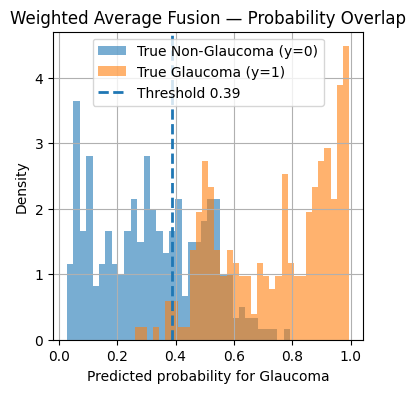

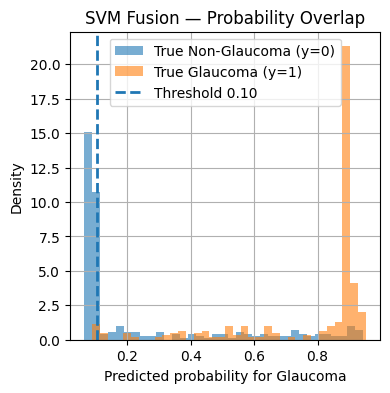

In [22]:
# Plot probability distributions for glaucoma vs non-glaucoma for each fusion strategy.
# # - Shows how well each fusion separates the two classes.

def plot_overlap_hist(y_true, y_prob, bins=35, thr_line=None, title=""):
    neg = y_prob[y_true == 0]
    pos = y_prob[y_true == 1]
    plt.figure(figsize=(4, 4))
    plt.hist(neg, bins=bins, alpha=0.6, density=True, label="True Non-Glaucoma (y=0)")
    plt.hist(pos, bins=bins, alpha=0.6, density=True, label="True Glaucoma (y=1)")
    if thr_line is not None:
        plt.axvline(thr_line, linestyle="--", linewidth=2, label=f"Threshold {thr_line:.2f}")
    plt.title(title)
    plt.xlabel("Predicted probability for Glaucoma")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_overlap_hist(y_test_true, y_test_prob_weighted, bins=35,
                  thr_line=best_thr_youden_weighted,
                  title="Weighted Average Fusion — Probability Overlap")

plot_overlap_hist(y_test_true, y_test_prob_svm, bins=35,
                  thr_line=best_thr_youden_svm,
                  title="SVM Fusion — Probability Overlap")

## 16. ROC Curve Comparison

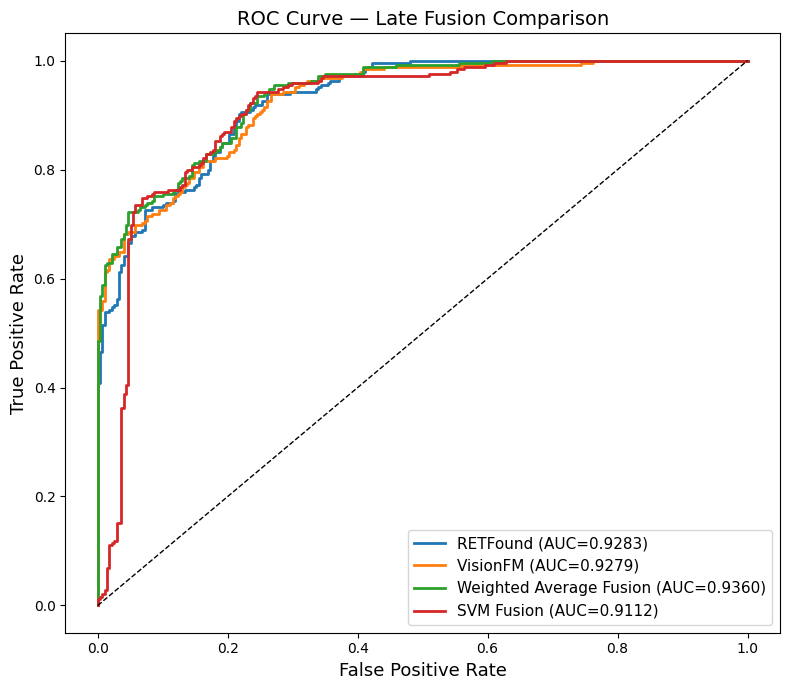

In [23]:
# Plot ROC curves for all four variants on the same figure.
# # - Allows direct visual comparison of individual vs fused model performance.

plt.figure(figsize=(8, 7))

for label, y_prob in [
    ("RETFound",                y_test_prob_r),
    ("VisionFM",                y_test_prob_v),
    ("Weighted Average Fusion", y_test_prob_weighted),
    ("SVM Fusion",              y_test_prob_svm),
]:
    fpr, tpr, _ = roc_curve(y_test_true, y_prob)
    auc = roc_auc_score(y_test_true, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{label} (AUC={auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("ROC Curve — Late Fusion Comparison", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(r"D:\Rama\Rama_Final\Fusion_Models", "fusion_roc_comparison.png"), dpi=150)  
plt.show()

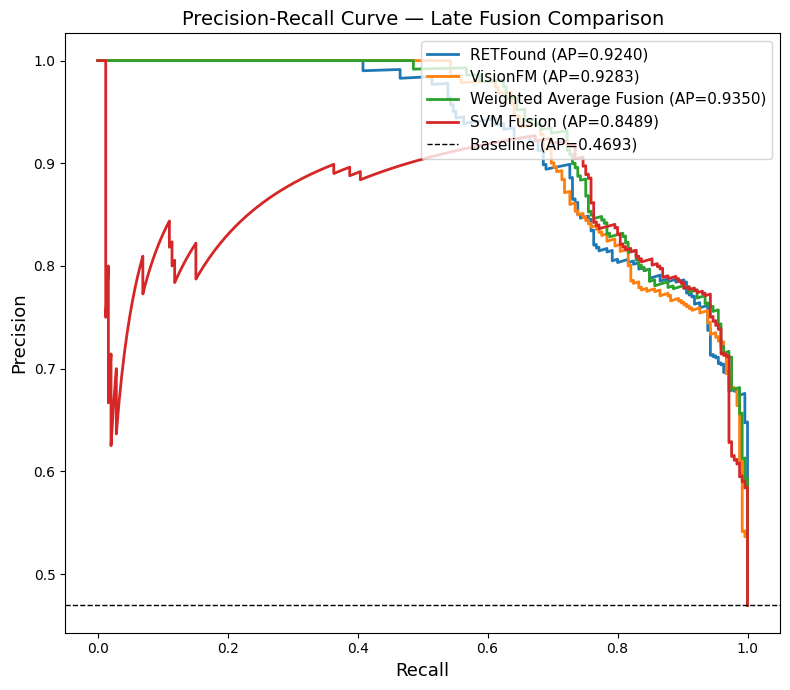

In [24]:
# precision recall curve 
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 7))
for label, y_prob in [
    ("RETFound",                y_test_prob_r),
    ("VisionFM",                y_test_prob_v),
    ("Weighted Average Fusion", y_test_prob_weighted),
    ("SVM Fusion",              y_test_prob_svm),
]:
    precision, recall, _ = precision_recall_curve(y_test_true, y_prob)
    ap = average_precision_score(y_test_true, y_prob)
    plt.plot(recall, precision, lw=2, label=f"{label} (AP={ap:.4f})")

# Baseline — random classifier (proportion of positives)
baseline = y_test_true.sum() / len(y_test_true)
plt.axhline(y=baseline, color="k", linestyle="--", lw=1, label=f"Baseline (AP={baseline:.4f})")

plt.xlabel("Recall", fontsize=13)
plt.ylabel("Precision", fontsize=13)
plt.title("Precision-Recall Curve — Late Fusion Comparison", fontsize=14)
plt.legend(loc="upper right", fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(r"D:\Rama\Rama_Final\Fusion_Models", "fusion_pr_comparison.png"), dpi=150)
plt.show()

## 19. Save Fusion Results

In [25]:
# Save the trained SVM and scaler as a pickle file for future inference.
# # - Also saves all test AUC scores, weights, and thresholds to a JSON summary file.

import pickle

#OUTPUT_DIR = r"D:\Rama\Glaucoma test\Fusion\last_weighte_lateFusion"
OUTPUT_DIR = r"D:\Rama\Rama_Final"
os.makedirs(OUTPUT_DIR, exist_ok=True)

svm_save = {
    "svm":                      svm,
    "scaler":                   scaler,
    "best_thr_youden_svm":      float(best_thr_youden_svm),
    "best_thr_youden_weighted": float(best_thr_youden_weighted),
    "retfound_weight":          float(w_r),
    "visionfm_weight":          float(w_v),
}
svm_path = os.path.join(OUTPUT_DIR, "fusion_svm.pkl")
with open(svm_path, "wb") as f:
    pickle.dump(svm_save, f)
print(f" SVM model saved → {svm_path}")

fusion_results = {
    "retfound_test_auc":                float(roc_auc_score(y_test_true, y_test_prob_r)),
    "visionfm_test_auc":                float(roc_auc_score(y_test_true, y_test_prob_v)),
    "weighted_fusion_test_auc":         float(roc_auc_score(y_test_true, y_test_prob_weighted)),
    "svm_fusion_test_auc":              float(roc_auc_score(y_test_true, y_test_prob_svm)),
    "retfound_weight":                  float(w_r),
    "visionfm_weight":                  float(w_v),
    "weighted_fusion_youden_threshold": float(best_thr_youden_weighted),
    "svm_fusion_youden_threshold":      float(best_thr_youden_svm),
}

json_path = os.path.join(OUTPUT_DIR, "fusion_late_results.json")
with open(json_path, "w") as f:
    json.dump(fusion_results, f, indent=4)

print(f" Fusion results saved → {json_path}")
print("\nSummary:")
for k, v in fusion_results.items():
    print(f"  {k:<40} : {v:.4f}")

 SVM model saved → D:\Rama\Rama_Final\fusion_svm.pkl
 Fusion results saved → D:\Rama\Rama_Final\fusion_late_results.json

Summary:
  retfound_test_auc                        : 0.9283
  visionfm_test_auc                        : 0.9279
  weighted_fusion_test_auc                 : 0.9360
  svm_fusion_test_auc                      : 0.9112
  retfound_weight                          : 0.5044
  visionfm_weight                          : 0.4956
  weighted_fusion_youden_threshold         : 0.3880
  svm_fusion_youden_threshold              : 0.1031


# Intermediate fusion — RETFound + VisionFM (Concat + Cross-Attention)

In [26]:
import os
import sys
import random
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, f1_score
)

In [28]:
def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seed(42)
print("Seed set to 42")

# Output folder — change this path 
#OUTPUT_DIR = r"D:\Rama\Glaucoma test\Fusion\last_intermediate_fusion_0.3"   # <- change this path

OUTPUT_DIR =r"D:\Rama\Rama_Final\intermediate_fusion_trying"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output folder: {OUTPUT_DIR}")

Seed set to 42
Output folder: D:\Rama\Rama_Final\intermediate_fusion_trying


## 1. Load RETFound

In [29]:
sys.path.insert(0, r"C:\Users\Rama Alotaibi\RETFound")   # <- RETFound repo path
from models_vit import RETFound_mae

retfound = RETFound_mae(num_classes=2)
original_head = retfound.head
retfound.head = nn.Sequential(
    nn.Dropout(p=0.3),
    original_head
)

retfound_checkpoint = torch.load(
    r"D:\Rama\Glaucoma test\RETFound\Weights\RetFound_Wieghts\LocalPublic_retfound_glaucoma_FULL.pth",   # <- RETFound weights path
    map_location="cpu",
    weights_only=False
)

retfound.load_state_dict(
    retfound_checkpoint["model_state_dict"],
    strict=False
)

import types
def fixed_forward(self, x):
    x = self.forward_features(x)
    x = self.forward_head(x)
    return x
retfound.forward = types.MethodType(fixed_forward, retfound)

for param in retfound.parameters():
    param.requires_grad = False
retfound.eval()

RETFOUND_DIM = original_head.in_features

print("RETFound loaded, frozen, and ready")
print(f"RETFound embedding dim : {RETFOUND_DIM}")
print(f"Best Val AUC from training: {retfound_checkpoint['best_val_auc']:.4f}")

RETFound loaded, frozen, and ready
RETFound embedding dim : 1024
Best Val AUC from training: 0.9073


## 2. Load VisionFM

In [30]:
VISIONFM_DIR   = r"D:\Rama\Glaucoma test\VisionFM\VisionFM"   # <- VisionFM repo path
EVALUATION_DIR = os.path.join(VISIONFM_DIR, 'evaluation')

os.chdir(VISIONFM_DIR)
sys.path.insert(0, EVALUATION_DIR)
sys.path.insert(0, VISIONFM_DIR)

import models
import utils

N_LAST_BLOCKS = 4

visionfm_backbone = models.__dict__['vit_base'](
    img_size=[224],
    patch_size=16,
    num_classes=0,
    use_mean_pooling=False
)

visionfm_checkpoint = torch.load(
    r"D:\Rama\Glaucoma test\VisionFM\Weights\VisionFM_glaucoma_Weightes\VisionFM_glaucoma_Weightes_FULL.pth",   # <- VisionFM weights path
    map_location="cpu",
    weights_only=False
)

visionfm_backbone.load_state_dict(visionfm_checkpoint["backbone_state_dict"])

for param in visionfm_backbone.parameters():
    param.requires_grad = False
visionfm_backbone.eval()

VISIONFM_DIM = visionfm_backbone.embed_dim * N_LAST_BLOCKS

print("VisionFM backbone loaded, frozen, and ready")
print(f"VisionFM embedding dim : {VISIONFM_DIM}")
print(f"Best Val AUC from training: {visionfm_checkpoint['best_auc']:.4f}")

VisionFM backbone loaded, frozen, and ready
VisionFM embedding dim : 3072
Best Val AUC from training: 0.8918


## 3. Build Intermediate Fusion Model

In [31]:
#  Fusion hyperparameters 
# Reduced capacity to handle small dataset (2600 images)
FUSION_DIM  = 256    # reduced from 512 — less capacity = less overfitting
NHEADS      = 4      # must divide FUSION_DIM evenly: 256/4 = 64 per head
NUM_CLASSES = 2
DROPOUT     = 0.3    


class CrossAttentionFusion(nn.Module):
    """
    Intermediate fusion: Concat + Cross-Attention.
    Step 1 — Project both feature vectors into shared FUSION_DIM space.
    Step 2 — Cross-Attention: RETFound queries VisionFM.
    Step 3 — Residual + LayerNorm.
    Step 4 — Concatenate attended features + original VisionFM projection.
    Step 5 — Single FFN layer (simplified for small dataset).
    Step 6 — Classifier head.
    """

    def __init__(self, retfound_dim, visionfm_dim, fusion_dim, nheads, num_classes, dropout):
        super().__init__()

        # Step 1: Projection heads
        self.proj_r = nn.Sequential(
            nn.Linear(retfound_dim, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.proj_v = nn.Sequential(
            nn.Linear(visionfm_dim, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Step 2: Cross-Attention
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=nheads,
            dropout=dropout,
            batch_first=True
        )

        # Step 3: Residual normalisation
        self.norm = nn.LayerNorm(fusion_dim)

        # Step 5: Single FFN layer (simplified — better for small dataset)
        self.ffn = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Step 6: Classifier
        self.classifier = nn.Linear(fusion_dim, num_classes)

    def extract_retfound_features(self, retfound_model, x):
        with torch.no_grad():
            feats = retfound_model.forward_features(x)
        return feats

    def extract_visionfm_features(self, visionfm_backbone, x, n_last_blocks):
        with torch.no_grad():
            intermediate = visionfm_backbone.get_intermediate_layers(x, n_last_blocks)
            feats = torch.cat([layer[:, 0] for layer in intermediate], dim=-1)
        return feats

    def forward(self, f_r, f_v):
        # Step 1 — Project to shared space
        p_r = self.proj_r(f_r)   # [B, fusion_dim]
        p_v = self.proj_v(f_v)   # [B, fusion_dim]

        # Step 2 — Cross-Attention
        p_r_seq = p_r.unsqueeze(1)   # [B, 1, fusion_dim]
        p_v_seq = p_v.unsqueeze(1)   # [B, 1, fusion_dim]
        attended, _ = self.cross_attn(query=p_r_seq, key=p_v_seq, value=p_v_seq)
        attended = attended.squeeze(1)   # [B, fusion_dim]

        # Step 3 — Residual + LayerNorm
        attended = self.norm(attended + p_r)

        # Step 4 — Concatenate
        fused = torch.cat([attended, p_v], dim=-1)   # [B, fusion_dim * 2]

        # Step 5 — FFN
        fused = self.ffn(fused)   # [B, fusion_dim]

        # Step 6 — Classify
        logits = self.classifier(fused)   # [B, num_classes]
        return logits


fusion_model = CrossAttentionFusion(
    retfound_dim=RETFOUND_DIM,
    visionfm_dim=VISIONFM_DIM,
    fusion_dim=FUSION_DIM,
    nheads=NHEADS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)

trainable = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
print(f"Fusion model built")
print(f"Trainable parameters : {trainable:,}")
print(f"  RETFound dim  : {RETFOUND_DIM}")
print(f"  VisionFM dim  : {VISIONFM_DIM}")
print(f"  Fusion dim    : {FUSION_DIM}")
print(f"  Dropout       : {DROPOUT}")
print(f"  Heads         : {NHEADS}")

Fusion model built
Trainable parameters : 1,444,610
  RETFound dim  : 1024
  VisionFM dim  : 3072
  Fusion dim    : 256
  Dropout       : 0.3
  Heads         : 4


## 4. Dataset

In [32]:
base_dir = r"D:\Rama\Glaucoma test\Fusion\nonLabel_NGHA_resplit_60_20_20"   # <- dataset root

for split in ["training", "val", "test"]:
    print(f"\n{split.upper()}")
    for cls in ["A_non_glaucoma", "B_glaucoma"]:
        path = os.path.join(base_dir, split, cls)
        if os.path.isdir(path):
            print(f"  {cls}: {len(os.listdir(path))} images")


TRAINING
  A_non_glaucoma: 828 images
  B_glaucoma: 731 images

VAL
  A_non_glaucoma: 276 images
  B_glaucoma: 243 images

TEST
  A_non_glaucoma: 277 images
  B_glaucoma: 245 images


## 5. Transforms

In [33]:
visionfm_mean = visionfm_checkpoint["normalization"]["mean"]
visionfm_std  = visionfm_checkpoint["normalization"]["std"]

#  Training transforms — with augmentation to fight overfitting 
retfound_transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

visionfm_transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=visionfm_mean, std=visionfm_std),
])

#  Val/Test transforms — no augmentation 
retfound_transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

visionfm_transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=visionfm_mean, std=visionfm_std),
])

print("RETFound  normalization : ImageNet stats")
print(f"VisionFM  normalization : mean={visionfm_mean}, std={visionfm_std}")
print("Augmentation applied to training only")

RETFound  normalization : ImageNet stats
VisionFM  normalization : mean=(0.423737496137619, 0.2609460651874542, 0.128403902053833), std=(0.29482534527778625, 0.20167365670204163, 0.13668020069599152)
Augmentation applied to training only


## 6. Datasets & DataLoaders

In [34]:
class DualTransformDataset(Dataset):
    """
    Applies two transforms to the same PIL image.
    Returns (img_retfound, img_visionfm, label) per sample.
    Separate train/eval transforms supported.
    """
    def __init__(self, root, transform_r, transform_v):
        self.dataset     = datasets.ImageFolder(root=root)
        self.transform_r = transform_r
        self.transform_v = transform_v

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img_pil, label = self.dataset[idx]
        img_r = self.transform_r(img_pil)
        img_v = self.transform_v(img_pil)
        return img_r, img_v, label


# Training — augmented transforms
train_dataset = DualTransformDataset(
    f"{base_dir}/training",
    retfound_transform_train,
    visionfm_transform_train
)

# Val & Test — clean transforms, no augmentation
val_dataset  = DualTransformDataset(
    f"{base_dir}/val",
    retfound_transform_eval,
    visionfm_transform_eval
)
test_dataset = DualTransformDataset(
    f"{base_dir}/test",
    retfound_transform_eval,
    visionfm_transform_eval
)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=0, worker_init_fn=seed_worker, generator=g)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, num_workers=0)

print(f"Class mapping : {train_dataset.dataset.class_to_idx}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("DataLoaders ready")

Class mapping : {'A_non_glaucoma': 0, 'B_glaucoma': 1}
Train: 1559 | Val: 519 | Test: 522
DataLoaders ready


## 7. Device

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

retfound          = retfound.to(device)
visionfm_backbone = visionfm_backbone.to(device)
fusion_model      = fusion_model.to(device)

print(f"Models running on: {device}")

Models running on: cuda


## 8. Sanity Check

In [36]:
retfound.eval()
visionfm_backbone.eval()
fusion_model.eval()

img_r, img_v, labels = next(iter(test_loader))
img_r, img_v = img_r.to(device), img_v.to(device)

with torch.no_grad():
    f_r    = fusion_model.extract_retfound_features(retfound, img_r)
    f_v    = fusion_model.extract_visionfm_features(visionfm_backbone, img_v, N_LAST_BLOCKS)
    logits = fusion_model(f_r, f_v)

print(f"RETFound feature shape  : {f_r.shape}")
print(f"VisionFM feature shape  : {f_v.shape}")
print(f"Fusion output shape     : {logits.shape}")
print(f"NaN check               : {torch.isnan(logits).any().item()}")
print(f"Inf check               : {torch.isinf(logits).any().item()}")
print("\nSanity check passed")

D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:109: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn = (q @ k.transpose(-2, -1)) * self.scale
D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:113: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this 

RETFound feature shape  : torch.Size([8, 1024])
VisionFM feature shape  : torch.Size([8, 3072])
Fusion output shape     : torch.Size([8, 2])
NaN check               : False
Inf check               : False

Sanity check passed


C:\Users\Rama Alotaibi\anaconda3\envs\fusion_model\lib\site-packages\torch\nn\functional.py:6373: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn_output_weights = torch.bmm(q_scaled, k.transpose(-2, -1))
C:\Users\Rama Alotaibi\anaconda3\envs\fusion_model\lib\site-packages\torch\nn\functional.py:6378: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(Tru

## 9. Train Fusion Model

In [37]:
#  Training hyperparameters 
EPOCHS    = 50
LR        = 3e-4
PATIENCE  = 5    # increased from 5 — give model more time to stabilize

CRITERION = nn.CrossEntropyLoss()
optimizer = AdamW(
    filter(lambda p: p.requires_grad, fusion_model.parameters()),
    lr=LR, weight_decay=1e-3   # increased from 1e-4 — stronger regularization
)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

#  Tracking 
best_val_auc     = -1
patience_counter = 0
best_model_state = None
train_losses     = []
val_losses       = []

#  Training loop 
for epoch in range(EPOCHS):

    #  Train 
    fusion_model.train()
    retfound.eval()
    visionfm_backbone.eval()

    train_loss    = 0
    train_correct = 0
    train_total   = 0

    for img_r, img_v, labels in train_loader:
        img_r, img_v, labels = img_r.to(device), img_v.to(device), labels.to(device)

        f_r = fusion_model.extract_retfound_features(retfound, img_r)
        f_v = fusion_model.extract_visionfm_features(visionfm_backbone, img_v, N_LAST_BLOCKS)

        optimizer.zero_grad()
        logits = fusion_model(f_r, f_v)
        loss   = CRITERION(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = torch.argmax(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc      = train_correct / train_total
    train_losses.append(avg_train_loss)

    #  Validate 
    fusion_model.eval()

    val_loss = 0
    val_true = []
    val_prob = []

    with torch.no_grad():
        for img_r, img_v, labels in val_loader:
            img_r, img_v = img_r.to(device), img_v.to(device)

            f_r    = fusion_model.extract_retfound_features(retfound, img_r)
            f_v    = fusion_model.extract_visionfm_features(visionfm_backbone, img_v, N_LAST_BLOCKS)
            logits = fusion_model(f_r, f_v)
            loss   = CRITERION(logits, labels.to(device))
            probs  = torch.softmax(logits, dim=1)[:, 1]

            val_loss += loss.item()
            val_true.extend(labels.numpy())
            val_prob.extend(probs.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_true = np.array(val_true)
    val_prob = np.array(val_prob)

    if len(np.unique(val_true)) < 2:
        val_auc = float("nan")
    else:
        val_auc = roc_auc_score(val_true, val_prob)

    scheduler.step()

    #  Print every epoch 
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {avg_val_loss:.4f} | Val   AUC: {val_auc:.4f}")

    #  Save best model 
    if (not np.isnan(val_auc)) and (val_auc > best_val_auc):
        best_val_auc     = val_auc
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in fusion_model.state_dict().items()}
        print("checkmark Best model saved")
    else:
        patience_counter += 1

    #  Early stopping 
    if patience_counter >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# Load best weights back
fusion_model.load_state_dict(best_model_state)
fusion_model.eval()
print(f"\nBest Val AUC: {best_val_auc:.4f}")

C:\Users\Rama Alotaibi\anaconda3\envs\fusion_model\lib\site-packages\torch\autograd\graph.py:824: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/50
Train Loss: 0.5470 | Train Acc: 0.7191
Val   Loss: 0.3933 | Val   AUC: 0.9042
checkmark Best model saved


D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:109: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn = (q @ k.transpose(-2, -1)) * self.scale
D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:113: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this 

Epoch 2/50
Train Loss: 0.3843 | Train Acc: 0.7967
Val   Loss: 0.4392 | Val   AUC: 0.9076
checkmark Best model saved


D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:109: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn = (q @ k.transpose(-2, -1)) * self.scale
D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:113: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this 

...

Epoch 12/50
Train Loss: 0.3266 | Train Acc: 0.8275
Val   Loss: 0.3886 | Val   AUC: 0.9056


D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:109: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn = (q @ k.transpose(-2, -1)) * self.scale
D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:113: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this 

Epoch 13/50
Train Loss: 0.3407 | Train Acc: 0.8165
Val   Loss: 0.4055 | Val   AUC: 0.9109


D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:109: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn = (q @ k.transpose(-2, -1)) * self.scale
D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:113: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this 

Epoch 14/50
Train Loss: 0.3340 | Train Acc: 0.8198
Val   Loss: 0.3885 | Val   AUC: 0.9062
Early stopping triggered at epoch 14

Best Val AUC: 0.9132


## 10. Collect Probabilities

In [38]:
def collect_probs_fusion(loader):
    fusion_model.eval()
    retfound.eval()
    visionfm_backbone.eval()

    y_true, y_prob = [], []
    with torch.no_grad():
        for img_r, img_v, labels in loader:
            img_r, img_v = img_r.to(device), img_v.to(device)

            f_r    = fusion_model.extract_retfound_features(retfound, img_r)
            f_v    = fusion_model.extract_visionfm_features(visionfm_backbone, img_v, N_LAST_BLOCKS)
            logits = fusion_model(f_r, f_v)
            probs  = torch.softmax(logits, dim=1)[:, 1]

            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_prob)


print("Collecting probabilities...")
y_train_true, y_train_prob = collect_probs_fusion(train_loader)
y_val_true,   y_val_prob   = collect_probs_fusion(val_loader)
y_test_true,  y_test_prob  = collect_probs_fusion(test_loader)

print(f"Intermediate Fusion — Test AUC : {roc_auc_score(y_test_true, y_test_prob):.4f}")

D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:109: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn = (q @ k.transpose(-2, -1)) * self.scale
D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:113: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this 

Intermediate Fusion — Test AUC : 0.9285


## 11. Evaluation Metrics

In [39]:
N_BOOTSTRAP  = 1000
CI_ALPHA     = 0.95
RANDOM_STATE = 42

def metrics_at_threshold(y_true, y_prob, thr):
    y_pred      = (y_prob >= thr).astype(int)
    cm          = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = precision_score(y_true, y_pred, zero_division=0)
    f1          = f1_score(y_true, y_pred, zero_division=0)
    auc         = roc_auc_score(y_true, y_prob)
    return dict(TN=TN, FP=FP, FN=FN, TP=TP,
                accuracy=accuracy, sensitivity=sensitivity,
                specificity=specificity, precision=precision,
                f1=f1, auc=auc)

def youden_threshold(y_true_val, y_prob_val):
    fpr, tpr, thresholds = roc_curve(y_true_val, y_prob_val)
    best_idx = np.argmax(tpr - fpr)
    return thresholds[best_idx]

def bootstrap_ci(y_true, y_prob, threshold, n=N_BOOTSTRAP):
    metric_keys = ["auc", "accuracy", "sensitivity", "specificity", "precision", "f1"]
    records = {k: [] for k in metric_keys}
    idx_neg = np.where(y_true == 0)[0]
    idx_pos = np.where(y_true == 1)[0]
    rng = np.random.default_rng(RANDOM_STATE)
    for _ in range(n):
        boot_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
        boot_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
        idx = np.concatenate([boot_neg, boot_pos])
        m = metrics_at_threshold(y_true[idx], y_prob[idx], threshold)
        for k in metric_keys:
            records[k].append(m[k])
    lo = (1 - CI_ALPHA) / 2 * 100
    hi = (1 + CI_ALPHA) / 2 * 100
    return {k: (np.percentile(records[k], lo), np.percentile(records[k], hi)) for k in metric_keys}

def print_results(label, m, ci, thr):
    bar = "=" * 62
    print(f"\n{bar}")
    print(f"FINAL TEST RESULTS - {label}")
    print(f"Threshold : {thr:.4f}    (Bootstrap n={N_BOOTSTRAP}, CI={int(CI_ALPHA*100)}%)")
    print(bar)
    print(f"{'Metric':<14}  {'Value':>7}   {'95% CI':>20}")
    print("-" * 46)
    for name, key in [('AUC','auc'),('Accuracy','accuracy'),('Sensitivity','sensitivity'),
                      ('Specificity','specificity'),('Precision','precision'),('F1-score','f1')]:
        lo, hi_ = ci[key]
        print(f"{name:<14}  {m[key]:>7.4f}   [{lo:.4f} - {hi_:.4f}]")
    print(bar)
    print("\nConfusion Matrix:")
    print(f"              Predicted")
    print(f"              Non-Glau  Glaucoma")
    print(f"True Non-Glau    {m['TN']:4d}      {m['FP']:4d}")
    print(f"True Glaucoma    {m['FN']:4d}      {m['TP']:4d}")
    print(bar)

print("Metrics helpers ready")

Metrics helpers ready


## 12. Threshold Selection

In [40]:
FIXED_THRESHOLD_FUSION = 0.46
best_thr_youden_fusion = youden_threshold(y_val_true, y_val_prob)

print(f"Fixed threshold  - Intermediate Fusion : {FIXED_THRESHOLD_FUSION}")
print(f"Youden threshold - Intermediate Fusion : {best_thr_youden_fusion:.4f}")

Fixed threshold  - Intermediate Fusion : 0.46
Youden threshold - Intermediate Fusion : 0.3556


## 13. Fusion Results

In [41]:
m_fixed  = metrics_at_threshold(y_test_true, y_test_prob, FIXED_THRESHOLD_FUSION)
ci_fixed = bootstrap_ci(y_test_true, y_test_prob, FIXED_THRESHOLD_FUSION)
print_results(f"Intermediate Fusion - Fixed Threshold = {FIXED_THRESHOLD_FUSION}", m_fixed, ci_fixed, FIXED_THRESHOLD_FUSION)

m_youden  = metrics_at_threshold(y_test_true, y_test_prob, best_thr_youden_fusion)
ci_youden = bootstrap_ci(y_test_true, y_test_prob, best_thr_youden_fusion)
print_results("Intermediate Fusion - Youden Threshold", m_youden, ci_youden, best_thr_youden_fusion)


FINAL TEST RESULTS - Intermediate Fusion - Fixed Threshold = 0.46
Threshold : 0.4600    (Bootstrap n=1000, CI=95%)
Metric            Value                 95% CI
----------------------------------------------
AUC              0.9285   [0.9084 - 0.9485]
Accuracy         0.8218   [0.7893 - 0.8544]
Sensitivity      0.8122   [0.7592 - 0.8612]
Specificity      0.8303   [0.7870 - 0.8736]
Precision        0.8089   [0.7698 - 0.8528]
F1-score         0.8106   [0.7748 - 0.8474]

Confusion Matrix:
              Predicted
              Non-Glau  Glaucoma
True Non-Glau     230        47
True Glaucoma      46       199

FINAL TEST RESULTS - Intermediate Fusion - Youden Threshold
Threshold : 0.3556    (Bootstrap n=1000, CI=95%)
Metric            Value                 95% CI
----------------------------------------------
AUC              0.9285   [0.9084 - 0.9485]
Accuracy         0.7797   [0.7471 - 0.8123]
Sensitivity      0.9633   [0.9388 - 0.9878]
Specificity      0.6173   [0.5667 - 0.6715]
Precis

## 14. Training Curve — Overfitting Analysis

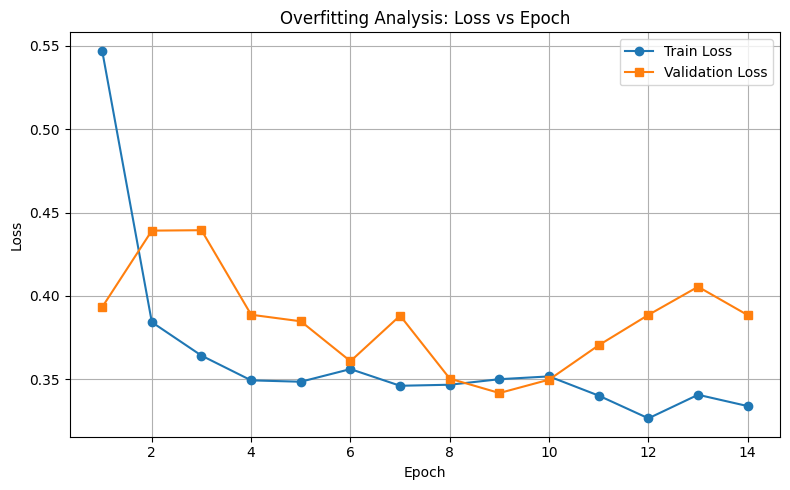

In [42]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker="o", label="Train Loss")
plt.plot(epochs_range, val_losses,   marker="s", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overfitting Analysis: Loss vs Epoch")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "intermediate_fusion_loss_curve.png"), dpi=150)
plt.show()

## 15. Probability Overlap Histogram

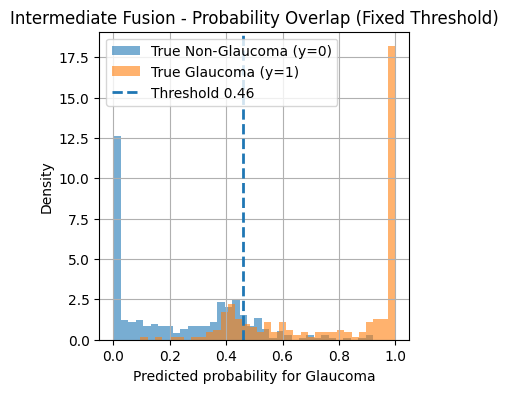

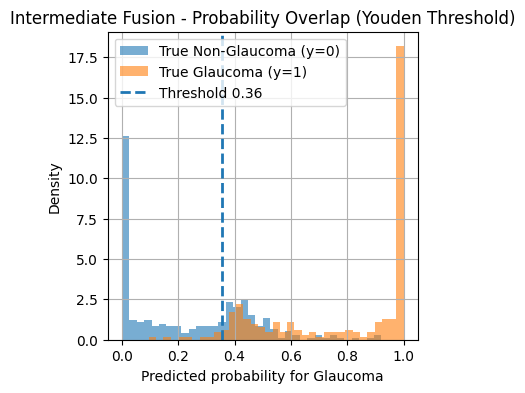

In [43]:
def plot_overlap_hist(y_true, y_prob, bins=35, thr_line=None, title=""):
    neg = y_prob[y_true == 0]
    pos = y_prob[y_true == 1]
    plt.figure(figsize=(4, 4))
    plt.hist(neg, bins=bins, alpha=0.6, density=True, label="True Non-Glaucoma (y=0)")
    plt.hist(pos, bins=bins, alpha=0.6, density=True, label="True Glaucoma (y=1)")
    if thr_line is not None:
        plt.axvline(thr_line, linestyle="--", linewidth=2, label=f"Threshold {thr_line:.2f}")
    plt.title(title)
    plt.xlabel("Predicted probability for Glaucoma")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_overlap_hist(y_test_true, y_test_prob, bins=35,
                  thr_line=FIXED_THRESHOLD_FUSION,
                  title="Intermediate Fusion - Probability Overlap (Fixed Threshold)")

plot_overlap_hist(y_test_true, y_test_prob, bins=35,
                  thr_line=best_thr_youden_fusion,
                  title="Intermediate Fusion - Probability Overlap (Youden Threshold)")

## 16. Save Fusion Model & Results

In [44]:
# FILE 1: Model weights (.pth)
model_save = {
    "model_state_dict": fusion_model.state_dict(),
    "best_val_auc":     float(best_val_auc),
    "config": {
        "retfound_dim":  RETFOUND_DIM,
        "visionfm_dim":  VISIONFM_DIM,
        "fusion_dim":    FUSION_DIM,
        "nheads":        NHEADS,
        "num_classes":   NUM_CLASSES,
        "dropout":       DROPOUT,
        "n_last_blocks": N_LAST_BLOCKS
    }
}
weights_path = os.path.join(OUTPUT_DIR, "intermediate_fusion_weights_full.pth")
torch.save(model_save, weights_path)
print(f" Weights saved    -> {weights_path}")

# FILE 2: Thresholds (.json)
thresholds_save = {
    "fixed_threshold":  float(FIXED_THRESHOLD_FUSION),
    "youden_threshold": float(best_thr_youden_fusion),
}
thresholds_path = os.path.join(OUTPUT_DIR, "intermediate_fusion_thresholds.json")
with open(thresholds_path, "w") as f:
    json.dump(thresholds_save, f, indent=4)
print(f" Thresholds saved -> {thresholds_path}")

# FILE 3: Results (.json)
fusion_results = {
    "test_auc":                        float(roc_auc_score(y_test_true, y_test_prob)),
    "best_val_auc":                    float(best_val_auc),
    "fixed_threshold":                 float(FIXED_THRESHOLD_FUSION),
    "fixed_accuracy":                  float(m_fixed["accuracy"]),
    "fixed_sensitivity":               float(m_fixed["sensitivity"]),
    "fixed_specificity":               float(m_fixed["specificity"]),
    "fixed_precision":                 float(m_fixed["precision"]),
    "fixed_f1":                        float(m_fixed["f1"]),
    "youden_threshold":                float(best_thr_youden_fusion),
    "youden_accuracy":                 float(m_youden["accuracy"]),
    "youden_sensitivity":              float(m_youden["sensitivity"]),
    "youden_specificity":              float(m_youden["specificity"]),
    "youden_precision":                float(m_youden["precision"]),
    "youden_f1":                       float(m_youden["f1"]),
    "youden_auc_ci":                   [float(ci_youden["auc"][0]),         float(ci_youden["auc"][1])],
    "youden_accuracy_ci":              [float(ci_youden["accuracy"][0]),    float(ci_youden["accuracy"][1])],
    "youden_sensitivity_ci":           [float(ci_youden["sensitivity"][0]), float(ci_youden["sensitivity"][1])],
    "youden_specificity_ci":           [float(ci_youden["specificity"][0]), float(ci_youden["specificity"][1])],
}
results_path = os.path.join(OUTPUT_DIR, "intermediate_fusion_results.json")
with open(results_path, "w") as f:
    json.dump(fusion_results, f, indent=4)
print(f" Results saved    -> {results_path}")

print("\n-- Saved files --------------------------------------")
print(f"  1. {os.path.basename(weights_path)}")
print(f"  2. {os.path.basename(thresholds_path)}")
print(f"  3. {os.path.basename(results_path)}")
print(f"  All in: {OUTPUT_DIR}")
print("\nSummary:")
for k, v in fusion_results.items():
    if isinstance(v, list):
        print(f"  {k:<35} : [{v[0]:.4f} - {v[1]:.4f}]")
    else:
        print(f"  {k:<35} : {v:.4f}")

 Weights saved    -> D:\Rama\Rama_Final\intermediate_fusion_trying\intermediate_fusion_weights_full.pth
 Thresholds saved -> D:\Rama\Rama_Final\intermediate_fusion_trying\intermediate_fusion_thresholds.json
 Results saved    -> D:\Rama\Rama_Final\intermediate_fusion_trying\intermediate_fusion_results.json

-- Saved files --------------------------------------
  1. intermediate_fusion_weights_full.pth
  2. intermediate_fusion_thresholds.json
  3. intermediate_fusion_results.json
  All in: D:\Rama\Rama_Final\intermediate_fusion_trying

Summary:
  test_auc                            : 0.9285
  best_val_auc                        : 0.9132
  fixed_threshold                     : 0.4600
  fixed_accuracy                      : 0.8218
  fixed_sensitivity                   : 0.8122
  fixed_specificity                   : 0.8303
  fixed_precision                     : 0.8089
  fixed_f1                            : 0.8106
  youden_threshold                    : 0.3556
  youden_accuracy           

## 17. ROC CURVE with intermediate fusion

In [46]:
#  LOAD INTERMEDIATE FUSION (CrossAttentionFusion) 

# Read config from checkpoint
intermediate_ckpt = torch.load(
    r"D:\Rama\Rama_Final\Fusion_Models\last_intermediate_fusion\intermediate_fusion_weights_full.pth",
    map_location=device,
    weights_only=False
)

config = intermediate_ckpt['config']

# Rebuild exact same architecture using saved config
class CrossAttentionFusion(nn.Module):
    def __init__(self, retfound_dim, visionfm_dim, fusion_dim, nheads, num_classes, dropout):
        super().__init__()
        self.proj_r = nn.Sequential(nn.Linear(retfound_dim, fusion_dim), nn.GELU(), nn.Dropout(dropout))
        self.proj_v = nn.Sequential(nn.Linear(visionfm_dim, fusion_dim), nn.GELU(), nn.Dropout(dropout))
        self.cross_attn = nn.MultiheadAttention(embed_dim=fusion_dim, num_heads=nheads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(fusion_dim)
        self.ffn = nn.Sequential(nn.Linear(fusion_dim * 2, fusion_dim), nn.GELU(), nn.Dropout(dropout))
        self.classifier = nn.Linear(fusion_dim, num_classes)

    def forward(self, f_r, f_v):
        p_r = self.proj_r(f_r)
        p_v = self.proj_v(f_v)
        p_r_seq = p_r.unsqueeze(1)
        p_v_seq = p_v.unsqueeze(1)
        attended, _ = self.cross_attn(query=p_r_seq, key=p_v_seq, value=p_v_seq)
        attended = attended.squeeze(1)
        attended = self.norm(attended + p_r)
        fused = torch.cat([attended, p_v], dim=-1)
        fused = self.ffn(fused)
        return self.classifier(fused)

fusion_model = CrossAttentionFusion(
    retfound_dim  = config['retfound_dim'],
    visionfm_dim  = config['visionfm_dim'],
    fusion_dim    = config['fusion_dim'],
    nheads        = config['nheads'],
    num_classes   = config['num_classes'],
    dropout       = config['dropout']
).to(device)

fusion_model.load_state_dict(intermediate_ckpt['model_state_dict'])
fusion_model.eval()
print(f"Intermediate fusion (CrossAttention) loaded ")
print(f"Best Val AUC from training: {intermediate_ckpt['best_val_auc']:.4f}")


Intermediate fusion (CrossAttention) loaded 
Best Val AUC from training: 0.9104


## COLLECT INTERMEDIATE FUSION PROBABILITIES

In [47]:

def collect_probs_intermediate(retfound_loader, visionfm_loader):
    retfound.eval()
    visionfm_backbone.eval()
    fusion_model.eval()
    y_true, y_prob = [], []

    N_LAST_BLOCKS_IF = config['n_last_blocks']

    with torch.no_grad():
        for (imgs_r, labels_r), (imgs_v, _) in zip(retfound_loader, visionfm_loader):
            imgs_r = imgs_r.to(device)
            imgs_v = imgs_v.to(device)

            # RETFound features
            feats_r = retfound.forward_features(imgs_r)
            if feats_r.dim() == 3:
                feats_r = feats_r[:, 0]

            # VisionFM features
            intermediate = visionfm_backbone.get_intermediate_layers(imgs_v, N_LAST_BLOCKS_IF)
            feats_v = torch.cat([x[:, 0] for x in intermediate], dim=-1)

            # Forward through fusion model
            logits = fusion_model(feats_r, feats_v)
            probs  = torch.softmax(logits, dim=1)[:, 1]

            y_true.extend(labels_r.numpy())
            y_prob.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_prob)

_, y_test_prob_intermediate = collect_probs_intermediate(
    retfound_test_loader, visionfm_test_loader
)

print(f"Intermediate Fusion test AUC: {roc_auc_score(y_test_true, y_test_prob_intermediate):.4f}")

D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:109: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn = (q @ k.transpose(-2, -1)) * self.scale
D:\Rama\Glaucoma test\VisionFM\VisionFM\models\vision_transformer.py:113: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this 

Intermediate Fusion test AUC: 0.9298


## RETFound + VisionFM only 

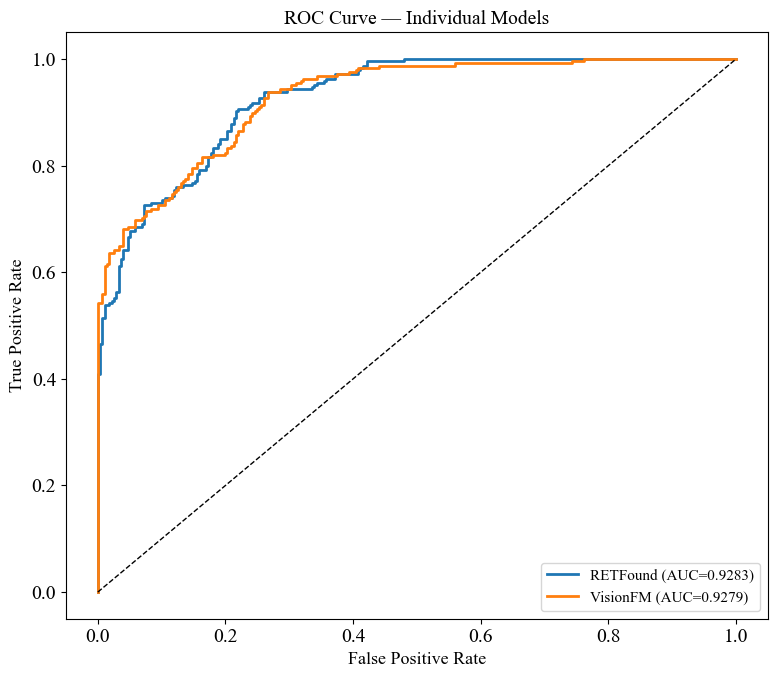

Curve 1 saved 


In [48]:
# ── Font settings ────────────────────────────────────────────────────────── 
plt.rcParams['font.family'] = 'Times New Roman' 
plt.rcParams['font.size'] = 14

plt.figure(figsize=(8, 7))

for label, y_prob in [
    ("RETFound",  y_test_prob_r),
    ("VisionFM",  y_test_prob_v),
]:
    fpr, tpr, _ = roc_curve(y_test_true, y_prob)
    auc = roc_auc_score(y_test_true, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{label} (AUC={auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("ROC Curve — Individual Models", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_individual_models.png"), dpi=150)
plt.show()
print("Curve 1 saved ")

## RETFound + VisionFM only with scikit learn precision recall curve

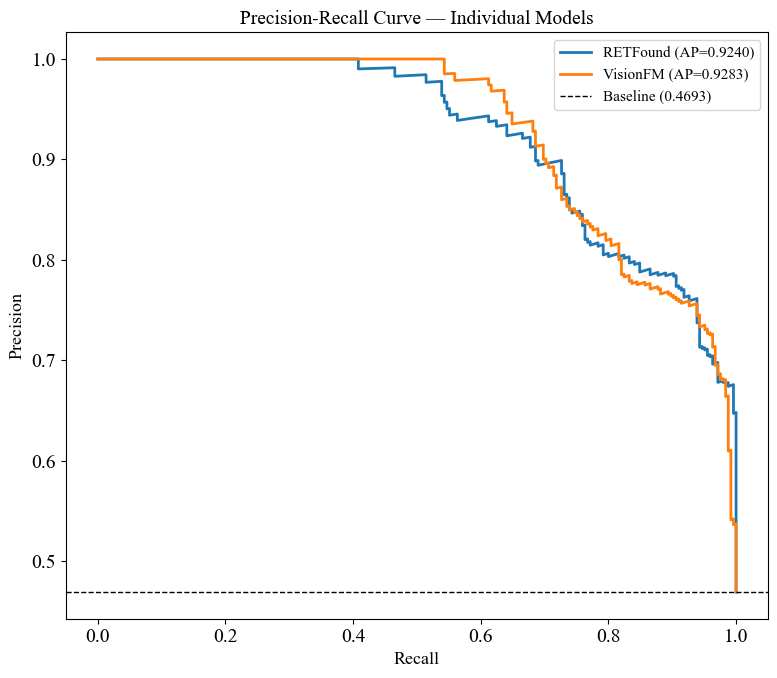

Curve 1 saved 


In [49]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# ── Font settings ────────────────────────────────────────────────────────── 
plt.rcParams['font.family'] = 'Times New Roman' 
plt.rcParams['font.size'] = 14

plt.figure(figsize=(8, 7))
for label, y_prob in [
    ("RETFound",  y_test_prob_r),
    ("VisionFM",  y_test_prob_v),
]:
    precision, recall, _ = precision_recall_curve(y_test_true, y_prob)
    ap = average_precision_score(y_test_true, y_prob)
    plt.plot(recall, precision, lw=2, label=f"{label} (AP={ap:.4f})")

baseline = y_test_true.sum() / len(y_test_true)
plt.axhline(y=baseline, color="k", linestyle="--", lw=1, label=f"Baseline ({baseline:.4f})")
plt.xlabel("Recall", fontsize=13)
plt.ylabel("Precision", fontsize=13)
plt.title("Precision-Recall Curve — Individual Models", fontsize=14)
plt.legend(loc="upper right", fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pr_individual_models.png"), dpi=150)
plt.show()
print("Curve 1 saved ")

## All models including intermediate fusion

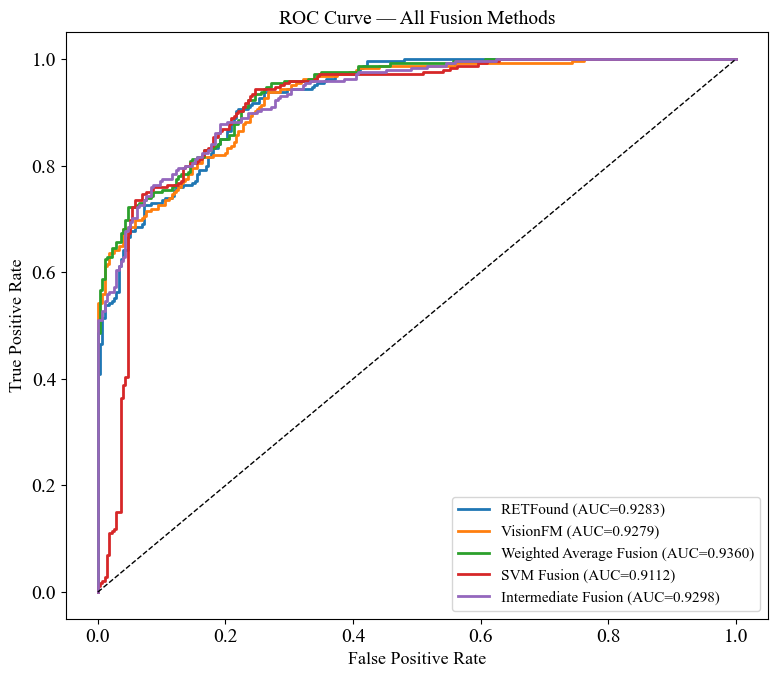

Curve 2 saved 


In [50]:
# ── Font settings ────────────────────────────────────────────────────────── 
plt.rcParams['font.family'] = 'Times New Roman' 
plt.rcParams['font.size'] = 14

plt.figure(figsize=(8, 7))

for label, y_prob in [
    ("RETFound",                  y_test_prob_r),
    ("VisionFM",                  y_test_prob_v),
    ("Weighted Average Fusion",   y_test_prob_weighted),
    ("SVM Fusion",                y_test_prob_svm),
    ("Intermediate Fusion",       y_test_prob_intermediate),
]:
    fpr, tpr, _ = roc_curve(y_test_true, y_prob)
    auc = roc_auc_score(y_test_true, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{label} (AUC={auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("ROC Curve — All Fusion Methods", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_all_fusion_methods.png"), dpi=150)
plt.show()
print("Curve 2 saved ")

## All models including intermediate fusion with scikit learn precision recall curve

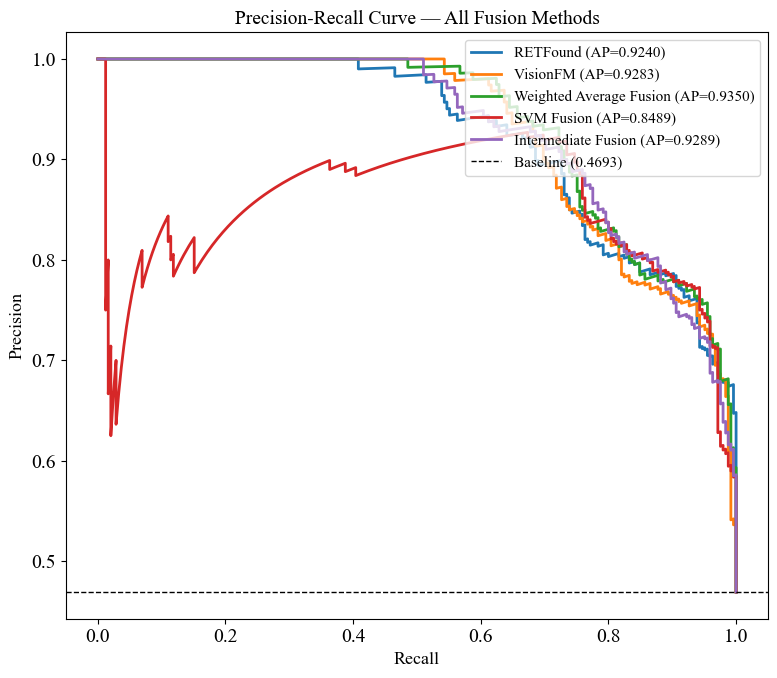

Curve 2 saved 


In [51]:
# ── Font settings ────────────────────────────────────────────────────────── 
plt.rcParams['font.family'] = 'Times New Roman' 
plt.rcParams['font.size'] = 14

plt.figure(figsize=(8, 7))
for label, y_prob in [
    ("RETFound",                  y_test_prob_r),
    ("VisionFM",                  y_test_prob_v),
    ("Weighted Average Fusion",   y_test_prob_weighted),
    ("SVM Fusion",                y_test_prob_svm),
    ("Intermediate Fusion",       y_test_prob_intermediate),
]:
    precision, recall, _ = precision_recall_curve(y_test_true, y_prob)
    ap = average_precision_score(y_test_true, y_prob)
    plt.plot(recall, precision, lw=2, label=f"{label} (AP={ap:.4f})")

baseline = y_test_true.sum() / len(y_test_true)
plt.axhline(y=baseline, color="k", linestyle="--", lw=1, label=f"Baseline ({baseline:.4f})")
plt.xlabel("Recall", fontsize=13)
plt.ylabel("Precision", fontsize=13)
plt.title("Precision-Recall Curve — All Fusion Methods", fontsize=14)
plt.legend(loc="upper right", fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pr_all_fusion_methods.png"), dpi=150)
plt.show()
print("Curve 2 saved ")